# Final Random Forest Test Set Evaluation

This notebook runs the chosen best model on the final locked test set.

The Random Forest was the best validation model, so here I retrain it using the train + validation data and evaluate it one time on `test_final.csv`.

## Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## Load final processed data

These are the final 18-feature files. The test set is only used here after the model choice was already made from validation results.

In [32]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

In [33]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)
Test shape: (2601, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


In [34]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Test columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN5

In [35]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTest target counts:")
print(test["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))
print("Test positive rate:", round(test["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Test target counts:
target
0    1299
1    1302
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5
Test positive rate: 0.501


## Separate features and target

I combined the train and validation sets because the validation set was already used to choose Random Forest as the best model. The final test set stays separate and is only used for the final evaluation.

In [36]:
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

train_val = pd.concat([train, validation], axis=0).reset_index(drop=True)

X_train_val = train_val[feature_cols]
y_train_val = train_val["target"]

X_test = test[feature_cols]
y_test = test["target"]

print("Number of features:", len(feature_cols))
print(feature_cols)

print("\nTrain + validation shape:", X_train_val.shape)
print("Test shape:", X_test.shape)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']

Train + validation shape: (10330, 18)
Test shape: (2601, 18)


In [37]:
print("Missing values in train + validation features:", X_train_val.isna().sum().sum())
print("Missing values in test features:", X_test.isna().sum().sum())

Missing values in train + validation features: 0
Missing values in test features: 0


## Train final Random Forest model

These are the best Random Forest settings from the validation experiment:

- `n_estimators = 500`
- `max_depth = 15`
- `min_samples_leaf = 8`
- `min_samples_split = 5`
- `max_features = 0.3`


In [38]:
final_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=8,
    min_samples_split=5,
    max_features=0.3,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_val, y_train_val)

RandomForestClassifier(max_depth=15, max_features=0.3, min_samples_leaf=8,
                       min_samples_split=5, n_estimators=500, n_jobs=-1,
                       random_state=42)

## Final test set results

In [39]:
test_pred = final_rf.predict(X_test)
test_prob = final_rf.predict_proba(X_test)[:, 1]

final_test_results = {
    "model": "Final Random Forest",
    "training_data": "train + validation",
    "test_accuracy": accuracy_score(y_test, test_pred),
    "test_precision": precision_score(y_test, test_pred, zero_division=0),
    "test_recall": recall_score(y_test, test_pred, zero_division=0),
    "test_f1": f1_score(y_test, test_pred, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, test_prob)
}

final_test_results_df = pd.DataFrame([final_test_results])
final_test_results_df

,model,training_data,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Final Random Forest,train + validation,0.69281,0.687827,0.707373,0.697463,0.764885


The final model got **0.693 accuracy**, **0.688 precision**, **0.707 recall**, **0.697 F1-score**, and **0.765 ROC-AUC**. The ROC-AUC is the main result I care about here because it shows the model can separate Chagas-positive and Chagas-negative exams better than random guessing. The recall of **0.707** also means the model caught about 71% of the positive test cases.

## Confusion matrix

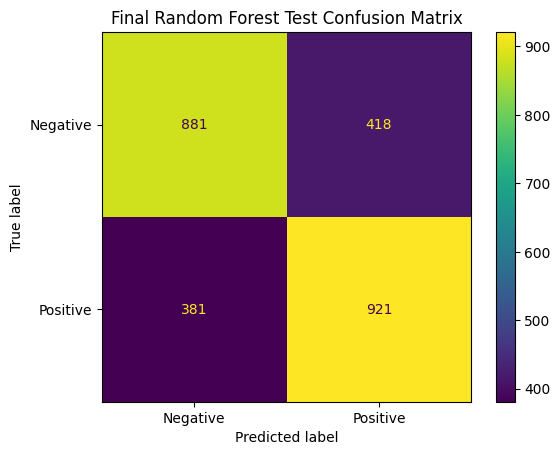

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("Final Random Forest Test Confusion Matrix")
plt.show()

The confusion matrix gives a more detailed look at the final Random Forest test results. The model correctly predicted **881 negative exams** and **921 positive exams**. It also incorrectly flagged **418 negative exams as positive** and missed **381 actual positive exams**. For this project, the false negatives are especially important because those are Chagas-positive exams that the model failed to catch. The model still missed some positives, but it caught **921 out of 1,302** positive test cases, which matches the recall of about **0.707**.

## ROC curve

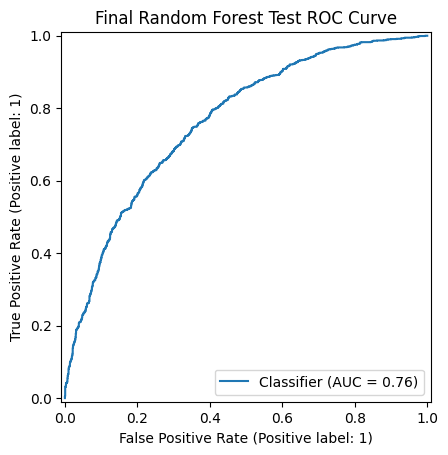

In [41]:
RocCurveDisplay.from_predictions(y_test, test_prob)

plt.title("Final Random Forest Test ROC Curve")
plt.show()

The ROC curve shows that the final Random Forest model separates Chagas-positive and Chagas-negative exams better than random guessing. The final test ROC-AUC was about **0.765**, which was slightly better than the validation ROC-AUC of **0.752**.

## Feature importance

In [42]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
0,age,0.180440
12,ST_segment_mean,0.086122
15,HRV_SDNN,0.073979
6,PR_segment_mean,0.069028
16,HRV_RMSSD,0.062249
10,QT_interval_mean,0.056698
11,QT_interval_std,0.056403
13,ST_segment_std,0.052424
8,QRS_duration_mean,0.052330
2,P_wave_duration_mean,0.048597


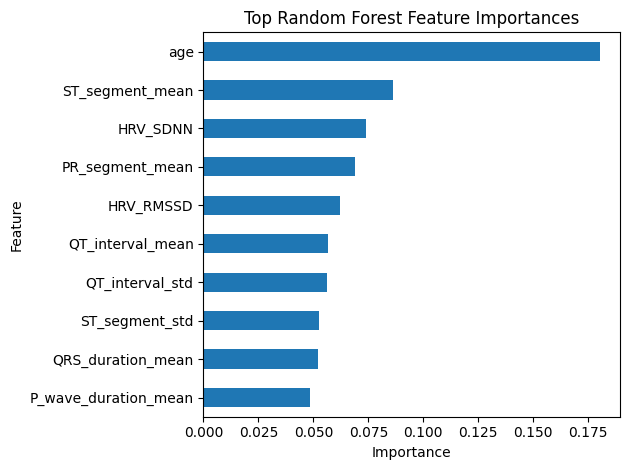

In [43]:
importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Age was the strongest feature by a good amount, followed by ECG timing features like ST segment mean, PR segment mean, QT interval, QRS duration, and HRV features. This lines up with the EDA because age and several ECG interval/segment features showed the strongest simple relationships with the target. The Random Forest was probably able to combine these weaker signals better than logistic regression or KNN.

## Subgroup check by sex

Since `is_male` is included in the dataset, I also check performance separately for male and female exams. This helps show whether the model performs similarly across sex groups.

In [44]:
subgroup_results = []

if "is_male" in test.columns:
    sex_values = sorted(test["is_male"].unique())

    for group_value, group_name in zip(sex_values, ["Female", "Male"]):
        mask = test["is_male"] == group_value

        subgroup_results.append({
            "subgroup": group_name,
            "n": int(mask.sum()),
            "accuracy": accuracy_score(y_test[mask], test_pred[mask]),
            "precision": precision_score(y_test[mask], test_pred[mask], zero_division=0),
            "recall": recall_score(y_test[mask], test_pred[mask], zero_division=0),
            "f1": f1_score(y_test[mask], test_pred[mask], zero_division=0),
            "roc_auc": roc_auc_score(y_test[mask], test_prob[mask])
        })

subgroup_results_df = pd.DataFrame(subgroup_results)
subgroup_results_df

,subgroup,n,accuracy,precision,recall,f1,roc_auc
0,Female,1612,0.674938,0.692029,0.680523,0.686228,0.742905
1,Male,989,0.721941,0.681018,0.756522,0.716787,0.803177


I checked performance separately by sex because `is_male` was included as a model feature. The model performed better on the male subgroup, with ROC-AUC of **0.803**, compared with **0.743** for the female subgroup.

## Save final outputs

In [45]:
results_dir = Path("final_model_results")
results_dir.mkdir(exist_ok=True)

final_test_results_df.to_csv(results_dir / "final_random_forest_test_results.csv", index=False)
importance_df.to_csv(results_dir / "final_random_forest_feature_importance.csv", index=False)

if len(subgroup_results_df) > 0:
    subgroup_results_df.to_csv(results_dir / "final_random_forest_subgroup_results.csv", index=False)

print("Saved final test results to final_model_results/")

Saved final test results to final_model_results/


## Conclusions

The Random Forest was selected as the final model because it had the strongest validation performance compared with the baseline, TensorFlow logistic regression, and KNN. The final test results were: **0.693 accuracy**, **0.688 precision**, **0.707 recall**, **0.697 F1-score**, and **0.765 ROC-AUC**. The model also caught **921 out of 1,302** positive Chagas exams, which is important because this project is more of a screening task.

Overall, the final Random Forest model performed better than the other models and generalized well to the test set. It is not accurate enough to be used as a standalone diagnosis tool, but it could be useful for screening or prioritizing patients for follow-up testing.